<a href="https://colab.research.google.com/github/Kichies/UTS-MachineLearning/blob/main/UTS_MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [6]:
print("======== Mengumpulkan & Memahami Data ========")
df = pd.read_csv('citrus.csv')
print("Preview Data:\n", df.head())
print("\nInfo Dataset (Baris, Kolom):", df.shape)
print("Distribusi Kelas:\n", df['name'].value_counts())
print("Cek Data Kosong:\n", df.isnull().sum())

======== Mengumpulkan & Memahami Data ========
Preview Data:
      name  diameter  weight  red  green  blue
0  orange      2.96   86.76  172     85     2
1  orange      3.91   88.05  166     78     3
2  orange      4.42   95.17  156     81     2
3  orange      4.47   95.60  163     81     4
4  orange      4.48   95.76  161     72     9

Info Dataset (Baris, Kolom): (10000, 6)
Distribusi Kelas:
 name
orange        5000
grapefruit    5000
Name: count, dtype: int64
Cek Data Kosong:
 name        0
diameter    0
weight      0
red         0
green       0
blue        0
dtype: int64


In [8]:
X = df.drop('name', axis=1)
y = df['name']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# SVM
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)


--- Hasil Evaluasi Akurasi ---
Decision Tree : 92.90%
Naive Bayes   : 92.60%
SVM           : 93.95%

File 'confusion_matrix.png' berhasil dibuat!


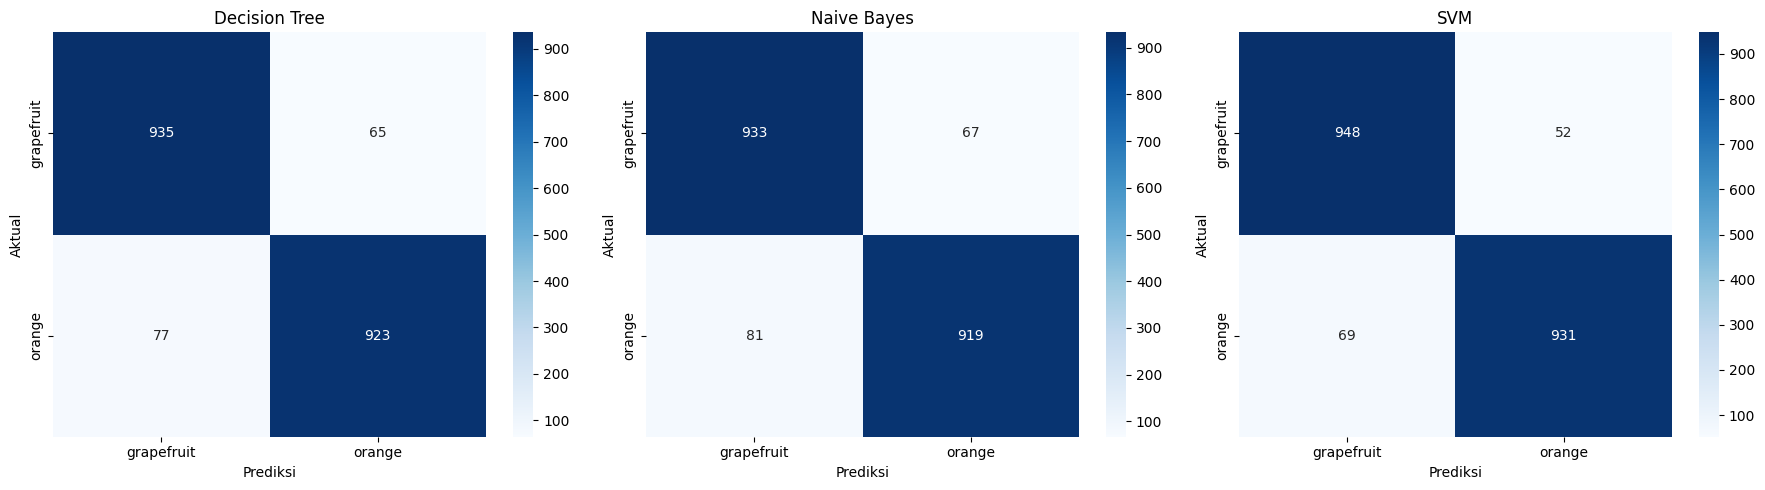

In [11]:
dt_pred = dt_model.predict(X_test)
nb_pred = nb_model.predict(X_test_scaled)
svm_pred = svm_model.predict(X_test_scaled)

# Hitung Akurasi
acc_dt = accuracy_score(y_test, dt_pred)
acc_nb = accuracy_score(y_test, nb_pred)
acc_svm = accuracy_score(y_test, svm_pred)

print("\n--- Hasil Evaluasi Akurasi ---")
print(f"Decision Tree : {acc_dt * 100:.2f}%")
print(f"Naive Bayes   : {acc_nb * 100:.2f}%")
print(f"SVM           : {acc_svm * 100:.2f}%")

# Membuat Visualisasi Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_info = [
    ("Decision Tree", confusion_matrix(y_test, dt_pred)),
    ("Naive Bayes", confusion_matrix(y_test, nb_pred)),
    ("SVM", confusion_matrix(y_test, svm_pred))
]

for ax, (title, cm) in zip(axes, models_info):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['grapefruit', 'orange'], yticklabels=['grapefruit', 'orange'])
    ax.set_title(title)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('confusion_matrix.png') # Menyimpan gambar
print("\nFile 'confusion_matrix.png' berhasil dibuat!")

In [12]:
best_model = max([("Decision Tree", acc_dt), ("Naive Bayes", acc_nb), ("SVM", acc_svm)], key=lambda item: item[1])
print(f"\nKesimpulan: Model terbaik adalah {best_model[0]} dengan akurasi {best_model[1] * 100:.2f}%")


Kesimpulan: Model terbaik adalah SVM dengan akurasi 93.95%
